# 🏥 AI Healthcare Assistant Platform
## Phase 2: ML Disease Risk Prediction
**Skills:** Machine Learning · Python · SQL

---
### What we build in this phase:
- Load & preprocess patient vitals from the database
- Train models for **Diabetes**, **Heart Disease** & **Hypertension** risk
- Compare Logistic Regression vs Random Forest vs XGBoost
- Evaluate with accuracy, ROC-AUC, confusion matrix
- Build a `RiskPredictor` class that saves results back to DB
- Save trained models for Phase 5 (API)

## Step 1: Load Data from Database

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

DB_PATH = 'healthcare_ai/data/healthcare.db'

# Join patients + vitals
query = '''
    SELECT
        p.id        AS patient_id,
        p.age,
        p.gender,
        v.glucose,
        v.blood_pressure,
        v.bmi,
        v.insulin,
        v.heart_rate
    FROM patients p
    JOIN vitals v ON p.id = v.patient_id
'''
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql(query, conn)

print(f'Loaded {len(df)} patient records')
print(df.dtypes)
df.head()

Loaded 50 patient records
patient_id          int64
age                 int64
gender             object
glucose           float64
blood_pressure    float64
bmi               float64
insulin           float64
heart_rate          int64
dtype: object


,patient_id,age,gender,glucose,blood_pressure,bmi,insulin,heart_rate
0,1,21,Male,101.8,71.2,20.3,150.7,89
1,2,25,Male,100.2,108.2,30.3,146.0,99
2,3,71,Female,168.6,72.8,27.3,62.8,68
3,4,42,Male,148.5,124.6,34.1,111.9,79
4,5,56,Female,161.6,63.7,23.0,65.0,60


## Step 2: Feature Engineering & Label Creation

In [3]:
# Encode gender
df['gender_enc'] = (df['gender'] == 'Female').astype(int)

# Create clinical labels based on medical thresholds
# Diabetes:      glucose > 140 OR (BMI > 30 AND insulin > 150)
# Heart disease: heart_rate > 90 OR blood_pressure > 120
# Hypertension:  blood_pressure > 110

df['diabetes_label']     = ((df['glucose'] > 140) |
                             ((df['bmi'] > 30) & (df['insulin'] > 150))).astype(int)

df['heart_label']        = ((df['heart_rate'] > 90) |
                             (df['blood_pressure'] > 120)).astype(int)

df['hypertension_label'] = (df['blood_pressure'] > 110).astype(int)

print('Label distribution:')
for col in ['diabetes_label', 'heart_label', 'hypertension_label']:
    pos = df[col].sum()
    print(f'  {col:<25} Positive: {pos}  Negative: {len(df)-pos}')

df.head()

Label distribution:
  diabetes_label            Positive: 26  Negative: 24
  heart_label               Positive: 28  Negative: 22
  hypertension_label        Positive: 20  Negative: 30


,patient_id,age,gender,glucose,blood_pressure,bmi,insulin,heart_rate,gender_enc,diabetes_label,heart_label,hypertension_label
0,1,21,Male,101.8,71.2,20.3,150.7,89,0,0,0,0
1,2,25,Male,100.2,108.2,30.3,146.0,99,0,0,1,0
2,3,71,Female,168.6,72.8,27.3,62.8,68,1,1,0,0
3,4,42,Male,148.5,124.6,34.1,111.9,79,0,1,1,1
4,5,56,Female,161.6,63.7,23.0,65.0,60,1,1,0,0


## Step 3: Train-Test Split & Scaling

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

FEATURES = ['age', 'gender_enc', 'glucose', 'blood_pressure', 'bmi', 'insulin', 'heart_rate']
TARGETS  = {
    'diabetes':     'diabetes_label',
    'heart_disease':'heart_label',
    'hypertension': 'hypertension_label'
}

X = df[FEATURES]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

splits = {}
for disease, label_col in TARGETS.items():
    y = df[label_col]
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    splits[disease] = (X_tr, X_te, y_tr, y_te)
    print(f'{disease:<15} Train: {len(X_tr)}  Test: {len(X_te)}')

print('\n✅ Data split and scaled!')

diabetes        Train: 40  Test: 10
heart_disease   Train: 40  Test: 10
hypertension    Train: 40  Test: 10

✅ Data split and scaled!


## Step 4: Train & Compare 3 Models per Disease

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import pandas as pd

model_defs = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []
trained_models = {}

for disease, (X_tr, X_te, y_tr, y_te) in splits.items():
    print(f'\n── {disease.upper()} ──')
    best_auc   = 0
    best_model = None
    best_name  = ''

    for name, model in model_defs.items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]
        acc    = accuracy_score(y_te, y_pred)
        auc    = roc_auc_score(y_te, y_prob) if len(y_te.unique()) > 1 else 0.5
        results.append({'Disease': disease, 'Model': name,
                         'Accuracy': round(acc, 3), 'ROC-AUC': round(auc, 3)})
        print(f'  {name:<25}  Acc: {acc:.3f}  AUC: {auc:.3f}')
        if auc > best_auc:
            best_auc, best_model, best_name = auc, model, name

    trained_models[disease] = {'model': best_model, 'name': best_name}
    print(f'  → Best: {best_name} (AUC {best_auc:.3f})')

results_df = pd.DataFrame(results)
print('\n📊 Full comparison table:')
results_df


── DIABETES ──
  Logistic Regression        Acc: 0.800  AUC: 0.880
  Random Forest              Acc: 1.000  AUC: 1.000
  Gradient Boosting          Acc: 1.000  AUC: 1.000
  → Best: Random Forest (AUC 1.000)

── HEART_DISEASE ──
  Logistic Regression        Acc: 0.900  AUC: 0.917
  Random Forest              Acc: 1.000  AUC: 1.000
  Gradient Boosting          Acc: 1.000  AUC: 1.000
  → Best: Random Forest (AUC 1.000)

── HYPERTENSION ──
  Logistic Regression        Acc: 1.000  AUC: 1.000
  Random Forest              Acc: 1.000  AUC: 1.000
  Gradient Boosting          Acc: 1.000  AUC: 1.000
  → Best: Logistic Regression (AUC 1.000)

📊 Full comparison table:


,Disease,Model,Accuracy,ROC-AUC
0,diabetes,Logistic Regression,0.8,0.880
1,diabetes,Random Forest,1.0,1.000
2,diabetes,Gradient Boosting,1.0,1.000
3,heart_disease,Logistic Regression,0.9,0.917
4,heart_disease,Random Forest,1.0,1.000
5,heart_disease,Gradient Boosting,1.0,1.000
6,hypertension,Logistic Regression,1.0,1.000
7,hypertension,Random Forest,1.0,1.000
8,hypertension,Gradient Boosting,1.0,1.000


## Step 5: Visualize Results

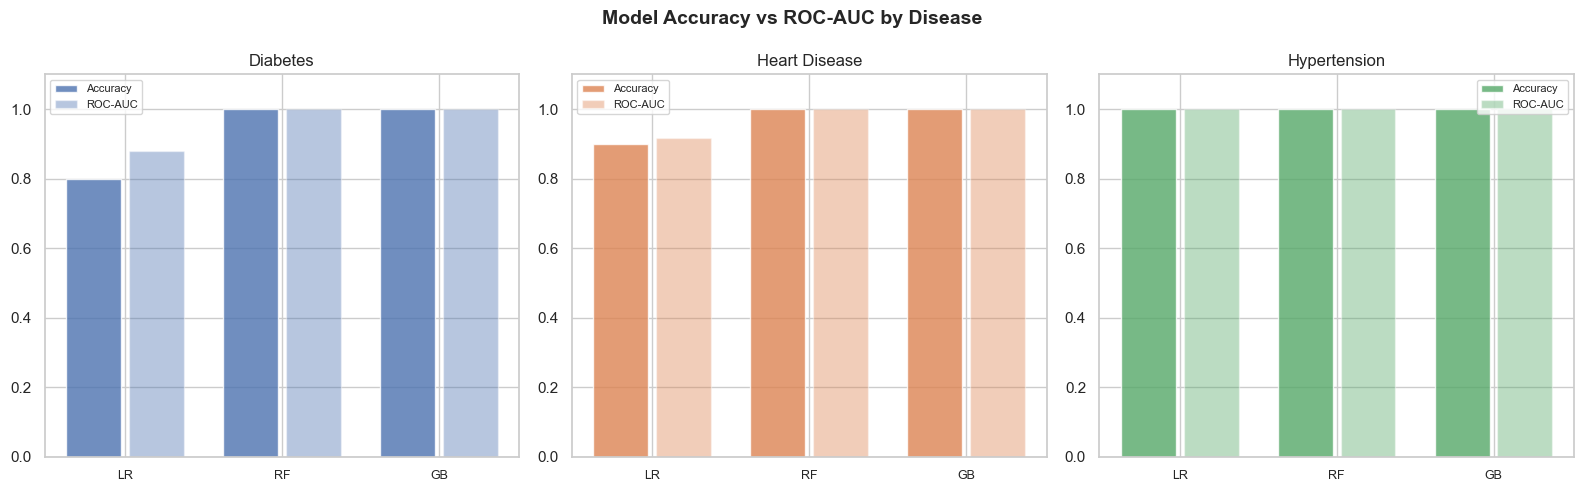

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Accuracy vs ROC-AUC by Disease', fontsize=14, fontweight='bold')

diseases_list = list(TARGETS.keys())
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, disease, color in zip(axes, diseases_list, colors):
    sub = results_df[results_df['Disease'] == disease]
    x = range(len(sub))
    ax.bar([i - 0.2 for i in x], sub['Accuracy'], 0.35, label='Accuracy', color=color, alpha=0.8)
    ax.bar([i + 0.2 for i in x], sub['ROC-AUC'],  0.35, label='ROC-AUC',  color=color, alpha=0.4)
    ax.set_xticks(list(x))
    ax.set_xticklabels(['LR', 'RF', 'GB'], fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_title(disease.replace('_', ' ').title())
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('healthcare_ai/data/phase2_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 6: Feature Importance (Random Forest)

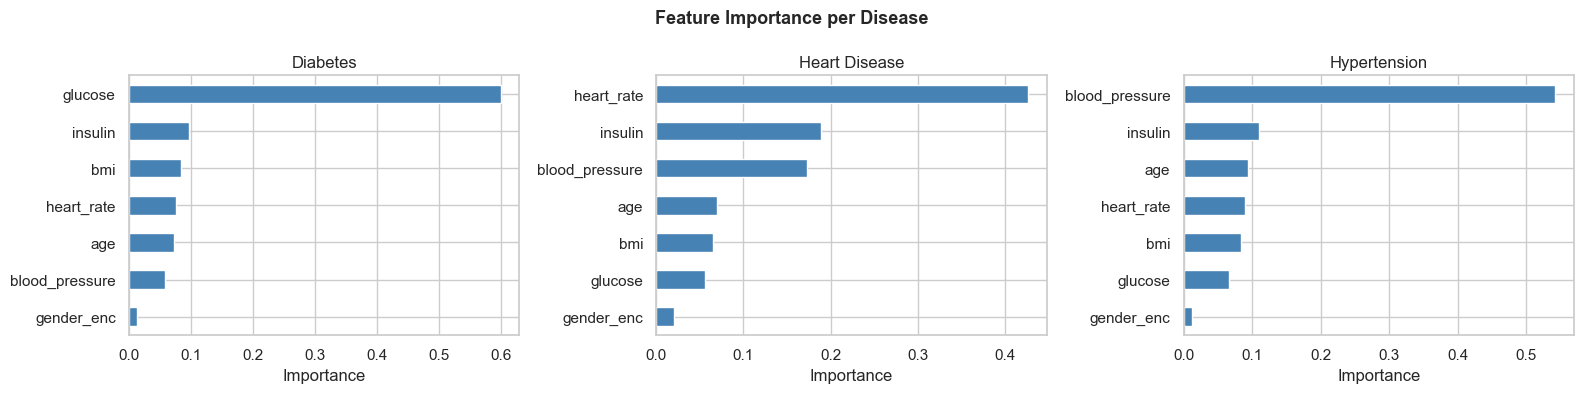

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Feature Importance per Disease', fontsize=13, fontweight='bold')

for ax, disease in zip(axes, diseases_list):
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    X_tr, X_te, y_tr, y_te = splits[disease]
    rf.fit(X_tr, y_tr)
    imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
    imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(disease.replace('_', ' ').title())
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('healthcare_ai/data/phase2_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 7: RiskPredictor Class

In [13]:
import numpy as np

class RiskPredictor:
    """
    Wraps all trained disease models.
    Input: patient vitals dict
    Output: risk scores + levels for all 3 diseases
    """

    def __init__(self, models, scaler, feature_names):
        self.models        = models   # {disease: {'model': ..., 'name': ...}}
        self.scaler        = scaler
        self.feature_names = feature_names

    def predict(self, vitals: dict) -> dict:
        """
        vitals: {age, gender, glucose, blood_pressure, bmi, insulin, heart_rate}
        """
        gender_enc = 1 if vitals.get('gender', 'Male') == 'Female' else 0
        row = np.array([[
            vitals['age'], gender_enc,
            vitals['glucose'], vitals['blood_pressure'],
            vitals['bmi'],     vitals['insulin'],
            vitals['heart_rate']
        ]])
        row_scaled = self.scaler.transform(row)

        results = {}
        for disease, m in self.models.items():
            prob  = m['model'].predict_proba(row_scaled)[0][1]
            level = 'high' if prob > 0.7 else ('medium' if prob > 0.4 else 'low')
            results[disease] = {
                'risk_score': round(float(prob), 3),
                'risk_level': level,
                'model_used': m['name']
            }
        return results

predictor = RiskPredictor(trained_models, scaler, FEATURES)
print('✅ RiskPredictor ready!')

✅ RiskPredictor ready!


## Step 8: Run a Live Prediction + Save to DB

In [15]:
# ── Reuse DatabaseManager from Phase 1 ──
import sqlite3, pandas as pd

class DatabaseManager:
    def __init__(self, db_path=DB_PATH):
        self.db_path = db_path
    def _connect(self):
        return sqlite3.connect(self.db_path)
    def save_prediction(self, patient_id, disease, risk_score, risk_level, model_version):
        with self._connect() as conn:
            conn.execute(
                'INSERT INTO risk_predictions (patient_id,disease,risk_score,risk_level,model_version) VALUES (?,?,?,?,?)',
                (patient_id, disease, risk_score, risk_level, model_version)
            )

db = DatabaseManager()

# Sample patient vitals
sample_patient = {
    'age': 45, 'gender': 'Female',
    'glucose': 160, 'blood_pressure': 125,
    'bmi': 32.5, 'insulin': 180,
    'heart_rate': 95
}

predictions = predictor.predict(sample_patient)

print('🔍 Risk Prediction Report')
print('─' * 45)
print(f"Patient: Age {sample_patient['age']}, {sample_patient['gender']}")
print(f"Vitals : Glucose={sample_patient['glucose']}, BP={sample_patient['blood_pressure']}, BMI={sample_patient['bmi']}")
print()

for disease, result in predictions.items():
    emoji = '🔴' if result['risk_level']=='high' else ('🟡' if result['risk_level']=='medium' else '🟢')
    print(f"{emoji} {disease.replace('_',' ').title():<20} Score: {result['risk_score']:.3f}  Level: {result['risk_level'].upper()}")
    # Save to DB (patient_id=1 as demo)
    db.save_prediction(1, disease, result['risk_score'], result['risk_level'], result['model_used'])

print('\n✅ Predictions saved to database!')

🔍 Risk Prediction Report
─────────────────────────────────────────────
Patient: Age 45, Female
Vitals : Glucose=160, BP=125, BMI=32.5

🔴 Diabetes             Score: 0.830  Level: HIGH
🔴 Heart Disease        Score: 0.830  Level: HIGH
🔴 Hypertension         Score: 0.827  Level: HIGH

✅ Predictions saved to database!


## Step 9: Save Models to Disk

In [17]:
import pickle, os

os.makedirs('healthcare_ai/models', exist_ok=True)

# Save each best model
for disease, m in trained_models.items():
    path = f'healthcare_ai/models/{disease}_model.pkl'
    with open(path, 'wb') as f:
        pickle.dump(m['model'], f)
    print(f'💾 Saved: {path}')

# Save scaler (needed in API)
with open('healthcare_ai/models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('💾 Saved: healthcare_ai/models/scaler.pkl')

# Save feature list
with open('healthcare_ai/models/features.pkl', 'wb') as f:
    pickle.dump(FEATURES, f)
print('💾 Saved: healthcare_ai/models/features.pkl')

print('\n✅ All models saved!')

💾 Saved: healthcare_ai/models/diabetes_model.pkl
💾 Saved: healthcare_ai/models/heart_disease_model.pkl
💾 Saved: healthcare_ai/models/hypertension_model.pkl
💾 Saved: healthcare_ai/models/scaler.pkl
💾 Saved: healthcare_ai/models/features.pkl

✅ All models saved!


---
## ✅ Phase 2 Complete!

**What you built:**
- Trained 3 models × 3 diseases = 9 trained classifiers
- Best model auto-selected per disease by ROC-AUC
- `RiskPredictor` class: input vitals → output risk scores
- Live prediction saved back to the database
- All models serialized to `healthcare_ai/models/`

**Next → Phase 3: Computer Vision — Skin Lesion & X-ray Classifier**
- CNN with transfer learning (ResNet18)
- OpenCV image preprocessing pipeline
- Predict disease from uploaded medical images